In [11]:
import numpy as np
import pandas as pd
df = pd.read_csv("/Users/serhatguldogan/Library/CloudStorage/OneDrive-KocUniversitesi/Project_/RAW DATA/BTC_1sec.csv")


In [12]:
df.head()

,Unnamed: 0,system_time,midpoint,spread,buys,sells,bids_distance_0,bids_distance_1,bids_distance_2,bids_distance_3,...,asks_market_notional_5,asks_market_notional_6,asks_market_notional_7,asks_market_notional_8,asks_market_notional_9,asks_market_notional_10,asks_market_notional_11,asks_market_notional_12,asks_market_notional_13,asks_market_notional_14
0,0,2021-04-07 11:32:42.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,2021-04-07 11:32:43.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,2021-04-07 11:32:44.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,2021-04-07 11:32:45.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,2021-04-07 11:32:46.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
prices=np.array(df["midpoint"])
np.size(prices)

1030728

In [14]:
p_uu = 0
p_ud = 0
p_du=0
p_dd=0
for i in range(np.size(prices)-2):
  
    
    if prices[i+1] > prices[i] and prices[i+2] > prices[i+1]:
        p_uu +=1
    if prices[i+1] > prices[i] and prices[i+2] < prices[i+1]:
        p_ud +=1
    
        
    if prices[i+1] < prices[i]:
        if prices [i+2] > prices[i+1]:
            p_du +=1
        if prices[i+2] < prices[i+1]:
            p_dd +=1
    




In [15]:
P_uu = (p_uu) / (p_uu + p_ud)
P_ud = 1- P_uu
P_du = (p_du) / (p_du + p_dd)
P_dd = 1 - P_du

In [16]:
M= np.array(([[P_uu,P_ud],[P_du,P_dd]]))
print(M)

[[0.59758503 0.40241497]
 [0.44562421 0.55437579]]


\pi =[0.52547614, 0.47452386]

In [17]:

as_mean = 0.5*(0.52547614-0.47452386)
as_mean
    
    

0.02547613999999998

Loading data...
Preparing data...
Calculating std for 120 window sizes...
Calculating std for 120 window sizes...
Calculation complete.

--- Results (first 5 rows) ---
   window_size_sec  empirical_std
0               10      21.950070
1               20      32.218122
2               30      41.202357
3               40      48.379201
4               50      54.440751

Plotting results (this should look like Figure 3)...

Regression coefficients (fitted on n >= 200):
Model: y = 25.176312 + 6.672734 * sqrt(x)
Intercept: 25.176312
Slope (C): 6.672734
Calculation complete.

--- Results (first 5 rows) ---
   window_size_sec  empirical_std
0               10      21.950070
1               20      32.218122
2               30      41.202357
3               40      48.379201
4               50      54.440751

Plotting results (this should look like Figure 3)...

Regression coefficients (fitted on n >= 200):
Model: y = 25.176312 + 6.672734 * sqrt(x)
Intercept: 25.176312
Slope (C): 6.672734


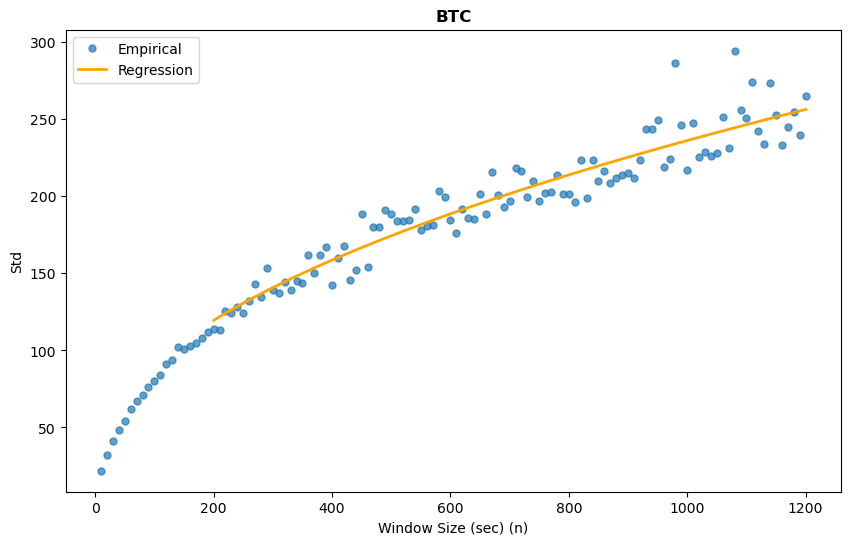

In [ ]:


def calculate_std_curve(input_df: pd.DataFrame, a_star: float, window_sizes_sec: list) -> pd.DataFrame:
    """
    Calculates the empirical standard deviation of the centered price process
    (S_j - N_j * a*) for various window sizes, using non-overlapping windows.

    This implements the "k to k+n, k+n to k+2n" logic.
    """
    
    print("Preparing data...")
    # --- 1. Prepare Data (One-time setup) ---
    df = input_df[['system_time', 'midpoint']].copy()
    
    if not pd.api.types.is_datetime64_any_dtype(df['system_time']):
        df['system_time'] = pd.to_datetime(df['system_time'])
        
    df = df.set_index('system_time').sort_index()
    
    # Calculate price changes (X_k in the paper)
    price_changes = df['midpoint'].diff().dropna()
    
    # Filter for non-zero changes, as N(t) counts *events*
    price_events_df = pd.DataFrame(price_changes[price_changes != 0])
    price_events_df.columns = ['price_change']

    results = []

    # --- 2. Loop Over All Window Sizes 'n' ---
    print(f"Calculating std for {len(window_sizes_sec)} window sizes...")
    for n_sec in window_sizes_sec:
        
        # This is the 'n' (window size)
        rule = f"{n_sec}S"
        
        # --- 3. Process data in chunks ---
        # This one line does the "k to k+n, k+n to k+2n" logic
        # It breaks the *entire* 'price_events_df' into non-overlapping chunks of size 'rule'
        resampler = price_events_df['price_change'].resample(rule)
        
        # --- 4. Calculate S_j and N_j for each chunk ---
        
        # S_j: Sum of price changes in each n-second chunk
        S_j_series = resampler.sum()
        
        # N_j: Count of price change events in each n-second chunk
        N_j_series = resampler.count()
        
        # --- 5. Calculate Y_j for each chunk ---
        # Y_j = S_j - N_j * a*
        Y_j_series = S_j_series - N_j_series * a_star
        
        # --- 6. Get the std for this window size 'n' ---
        # This calculates the std of the *list* [Y_1, Y_2, Y_3, ...]
        std_for_this_n = Y_j_series.std()
        
        results.append((n_sec, std_for_this_n))

    # --- 7. Return Results ---
    results_df = pd.DataFrame(results, columns=['window_size_sec', 'empirical_std'])
    
    print("Calculation complete.")
    return results_df

# ==================================================================
# --- SCRIPT TO PASTE AND RUN ---
# ==================================================================

# 1. Load your data
print("Loading data...")


# 2. SET YOUR a* VALUE HERE
A_STAR = 0.025476139999999984

# 3. Define the list of 'n' values to test (in seconds)
# (from 10s to 1200s, like the paper)
window_sizes = np.arange(10, 1201, 10)

# 4. Run the calculation
std_results = calculate_std_curve(df, A_STAR, window_sizes)

# 5. Print and Plot the results
print("\n--- Results (first 5 rows) ---")
print(std_results.head())

print("\nPlotting results (this should look like Figure 3)...")
plt.figure(figsize=(10, 6))
plt.plot(
    std_results['window_size_sec'], 
    std_results['empirical_std'], 
    'o', 
    label='Empirical',
    alpha=0.7,
    markersize=5
)

# Add regression line: y = C * sqrt(x), starting from n=200
x = std_results['window_size_sec'].values
y = std_results['empirical_std'].values

# Filter data for n >= 200
mask = x >= 200
x_filtered = x[mask]
y_filtered = y[mask]

# Fit model: std = C * sqrt(window_size) using only n >= 200
# Transform x to sqrt(x) and fit linear regression
x_sqrt_filtered = np.sqrt(x_filtered)
# Fit y = C * sqrt(x) (linear regression in transformed space)
coeffs = np.polyfit(x_sqrt_filtered, y_filtered, 1) 

# Print coefficients
print(f"\nRegression coefficients (fitted on n >= 200):")
print(f"Model: y = {coeffs[1]:.6f} + {coeffs[0]:.6f} * sqrt(x)")
print(f"Intercept: {coeffs[1]:.6f}")
print(f"Slope (C): {coeffs[0]:.6f}")

# Create smooth line for plotting, starting from n=200
x_smooth = np.linspace(200, x.max(), 300)
x_smooth_sqrt = np.sqrt(x_smooth)
regression_line = np.polyval(coeffs, x_smooth_sqrt)
plt.plot(x_smooth, regression_line, '-', label='Regression', color="orange", linewidth=2)




plt.title("BTC", fontweight='bold')
plt.xlabel('Window Size (sec) (n)')
plt.ylabel('Std')
plt.legend()

plt.show()


In [ ]:
coeffs

array([ 6.65630221, 25.43785048])

In [28]:
np.savetxt("std_results.csv",X=std_results,fmt="%f",delimiter=",")

coefficient = 25.43785048

In [ ]:
arr = []
for i in range(len(std_results["window_size_sec"])):
    k = regression_line[std_results["window_size_sec"][i]]-std_results["empirical_std"][i]
    c = k**2
    arr.append(c)

IndexError: index 300 is out of bounds for axis 0 with size 300

In [ ]:
std_results["window_size_sec"][119]

1200

In [ ]:
len(std_results["empirical_std"])

120